<a href="https://colab.research.google.com/github/2403a52264-debug/NLP/blob/main/2403a52264_NLP_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Firstly we are installing gensim files

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 43.1 MB/s eta 0:00:00


# Here we are importing numpy and genism model

In [4]:
import numpy as np
from gensim.models import KeyedVectors
import gensim.downloader as api

# we imported word embedding models word2vec model and glove model

In [6]:
word2vec_model = api.load("word2vec-google-news-300")
glove_model = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 1662.8/1662.8MB downloaded
[==================================================] 100.0% 128.1/128.1MB downloaded


# Listed few words into the list

In [18]:
words = [
    #seasons
    "summer","winter","monsoon","spring","autman",
    #Hardware Tools
    "hammer","screwdriver","tape measure","electric drill","adjustable wrench",
    #places
    "warangal","hyderabad","kamareddy","vijayawada","bangalore",
    #classroom
    "teacher","students","board","benches","fans",
    #house
    "garden","swimming pool","balcony","kitchen","bathroom",
    #sports
    "football","cricket","hockey","tennis","badminton",
    #food
    "biryani","apple","pizza","burger","momos",
    #colours
    "red","blue","yellow","purple","green",

]

# Here we converted list of words into vector form and reduced the dimensionality

In [19]:
vectors = [word2vec_model[word] for word in words if word in word2vec_model]
vectors_word2vec = np.array(vectors)
print("Total words selected:", len(words))
print("Vector shape:", vectors_word2vec.shape)
print(vectors_word2vec[0])


Total words selected: 40
Vector shape: (32, 300)
[ 0.06835938  0.31445312 -0.1953125   0.0378418  -0.08398438 -0.02148438
  0.09814453 -0.18359375 -0.00268555  0.17773438  0.02832031 -0.02709961
  0.05712891 -0.03808594 -0.03637695 -0.0378418  -0.12695312 -0.05175781
  0.03112793 -0.08251953 -0.05419922  0.32617188 -0.08007812 -0.11035156
 -0.25195312  0.03955078  0.3984375   0.10546875 -0.03735352  0.27148438
  0.08251953  0.09521484  0.07128906  0.17871094 -0.01855469 -0.17382812
 -0.24511719 -0.42578125 -0.06787109 -0.04150391  0.03100586 -0.19140625
  0.16894531 -0.03295898 -0.15429688 -0.06982422  0.04980469  0.16894531
  0.07128906  0.18847656  0.15039062 -0.18261719 -0.18359375 -0.02087402
  0.11083984  0.01794434  0.03540039 -0.10498047 -0.06225586 -0.12255859
 -0.11523438  0.03759766 -0.05664062  0.0123291  -0.01806641  0.03979492
 -0.09082031 -0.06787109  0.02490234 -0.04907227  0.21875    -0.02722168
  0.00518799  0.22949219  0.01782227  0.08300781 -0.02416992  0.05981445
  

# Here we converted list of words into vector form and reduced the dimensionality in glove model

In [21]:
vectors = [glove_model[word] for word in words if word in glove_model]
vectors_glove = np.array(vectors)
print("Total words selected:", len(words))
print("Vector shape:", vectors_word2vec.shape)
print(vectors_glove[0])

Total words selected: 40
Vector shape: (34, 100)
[ 2.2932e-01  2.9596e-01 -1.3595e-01 -2.7352e-01 -1.2198e-01 -2.7147e-01
  1.0636e-01  1.0227e+00 -7.8520e-01 -9.5019e-02 -9.4042e-02 -6.4040e-01
  3.5748e-01 -1.4664e-01 -8.7386e-02 -1.1400e-01 -5.7655e-02  2.8462e-02
 -3.2757e-01 -1.7158e-02 -2.7269e-01  3.6096e-01  4.8712e-01  4.8800e-01
 -2.8157e-01  2.9087e-01 -5.9077e-01 -6.7801e-01  1.1974e-01 -5.3354e-01
 -8.3428e-01  2.3900e-01  9.5356e-02 -3.9610e-01 -2.0898e-01  7.3556e-01
 -8.7348e-02  8.2249e-02 -2.5949e-01 -4.0660e-01 -2.8949e-01 -2.5994e-01
 -1.6372e-01  7.1773e-02  8.6667e-01 -1.0495e-01  3.6110e-01 -9.6978e-01
  1.0044e+00 -6.4153e-01  3.8452e-03 -6.9631e-01  3.6490e-01  5.1366e-01
  9.2129e-03 -2.9715e+00 -2.0650e-02  2.3161e-01  1.3420e+00  5.1555e-01
 -4.8805e-01  1.5071e+00 -1.3060e-01 -3.2415e-01  9.6814e-01 -1.4007e-02
  9.5845e-02 -8.0644e-01  3.3942e-01 -5.2325e-01  9.9921e-03 -6.5802e-01
 -5.7978e-01  5.1789e-01 -7.2129e-01  6.5524e-01  4.4394e-01 -3.1057e-02
 -

# We imported t-sne model to reduce the dimensionality into 2 dimension

In [33]:
from sklearn.manifold import TSNE
tsne = TSNE(
    n_components=3,
    random_state=42,
    perplexity=10,
    learning_rate=200
)
tsne_coordinates = tsne.fit_transform(vectors_word2vec)

print("Original Shape:", vectors_word2vec.shape)
print("Reduced Shape:", tsne_coordinates.shape)

# Displaying first 5 coordinates
print("\nFirst 5 t-SNE Coordinates:")
print(tsne_coordinates[:5])
# Displaying first 5 coordinates of word2vec
print("\nFirst 5 t-SNE Coordinates:")
print(vectors_word2vec[:5])

Original Shape: (34, 100)
Reduced Shape: (34, 3)

First 5 t-SNE Coordinates:
[[   15.360027   148.0003     -85.27523 ]
 [  -13.05452    229.22583   -217.06033 ]
 [   -7.022559  -330.27917    218.00162 ]
 [ -117.429375  -167.2813     119.548584]
 [-1055.097     1687.1206     426.9412  ]]

First 5 t-SNE Coordinates:
[[ 2.2932e-01  2.9596e-01 -1.3595e-01 -2.7352e-01 -1.2198e-01 -2.7147e-01
   1.0636e-01  1.0227e+00 -7.8520e-01 -9.5019e-02 -9.4042e-02 -6.4040e-01
   3.5748e-01 -1.4664e-01 -8.7386e-02 -1.1400e-01 -5.7655e-02  2.8462e-02
  -3.2757e-01 -1.7158e-02 -2.7269e-01  3.6096e-01  4.8712e-01  4.8800e-01
  -2.8157e-01  2.9087e-01 -5.9077e-01 -6.7801e-01  1.1974e-01 -5.3354e-01
  -8.3428e-01  2.3900e-01  9.5356e-02 -3.9610e-01 -2.0898e-01  7.3556e-01
  -8.7348e-02  8.2249e-02 -2.5949e-01 -4.0660e-01 -2.8949e-01 -2.5994e-01
  -1.6372e-01  7.1773e-02  8.6667e-01 -1.0495e-01  3.6110e-01 -9.6978e-01
   1.0044e+00 -6.4153e-01  3.8452e-03 -6.9631e-01  3.6490e-01  5.1366e-01
   9.2129e-03 -2.9

# Plotted the scatter plot using matplotlib

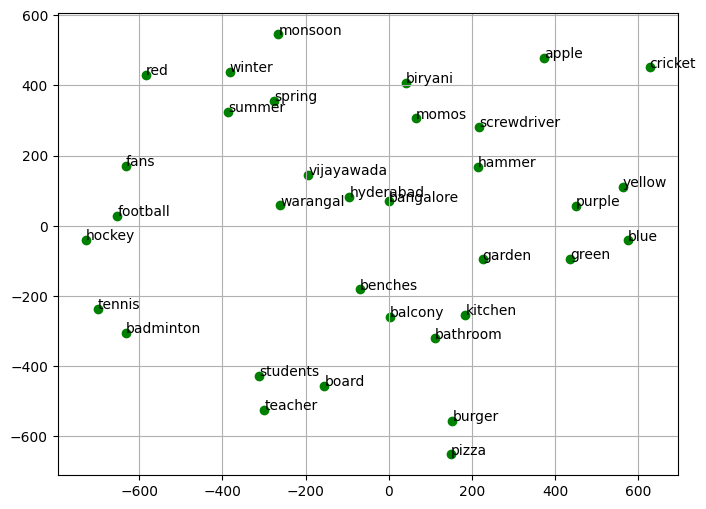

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(tsne_coordinates[:,0], tsne_coordinates[:,1],c = "green")
plt.grid()
filtered_words_for_tsne = [word for word in words if word in glove_model]

for i, word in enumerate(filtered_words_for_tsne):
    plt.annotate(word, (tsne_coordinates[i,0], tsne_coordinates[i,1]))

plt.show()

In [35]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=10,
    learning_rate=200
)

tsne_coordinates = tsne.fit_transform(vectors_glove)
print("Original Shape:", vectors_glove.shape)
print("Reduced Shape:", tsne_coordinates.shape)

# Displaying first 5 coordinates
print("\nFirst 5 t-SNE Coordinates:")
print(tsne_coordinates[:5])
# Displaying first 5 coordinates of glove
print("\nFirst 5 t-SNE Coordinates:")
print(vectors_glove[:5])

Original Shape: (34, 100)
Reduced Shape: (34, 2)

First 5 t-SNE Coordinates:
[[-386.672    325.15802]
 [-382.2102   437.74994]
 [-265.23206  545.7811 ]
 [-275.46503  356.8357 ]
 [ 214.38872  167.2736 ]]

First 5 t-SNE Coordinates:
[[ 2.2932e-01  2.9596e-01 -1.3595e-01 -2.7352e-01 -1.2198e-01 -2.7147e-01
   1.0636e-01  1.0227e+00 -7.8520e-01 -9.5019e-02 -9.4042e-02 -6.4040e-01
   3.5748e-01 -1.4664e-01 -8.7386e-02 -1.1400e-01 -5.7655e-02  2.8462e-02
  -3.2757e-01 -1.7158e-02 -2.7269e-01  3.6096e-01  4.8712e-01  4.8800e-01
  -2.8157e-01  2.9087e-01 -5.9077e-01 -6.7801e-01  1.1974e-01 -5.3354e-01
  -8.3428e-01  2.3900e-01  9.5356e-02 -3.9610e-01 -2.0898e-01  7.3556e-01
  -8.7348e-02  8.2249e-02 -2.5949e-01 -4.0660e-01 -2.8949e-01 -2.5994e-01
  -1.6372e-01  7.1773e-02  8.6667e-01 -1.0495e-01  3.6110e-01 -9.6978e-01
   1.0044e+00 -6.4153e-01  3.8452e-03 -6.9631e-01  3.6490e-01  5.1366e-01
   9.2129e-03 -2.9715e+00 -2.0650e-02  2.3161e-01  1.3420e+00  5.1555e-01
  -4.8805e-01  1.5071e+00 -1.

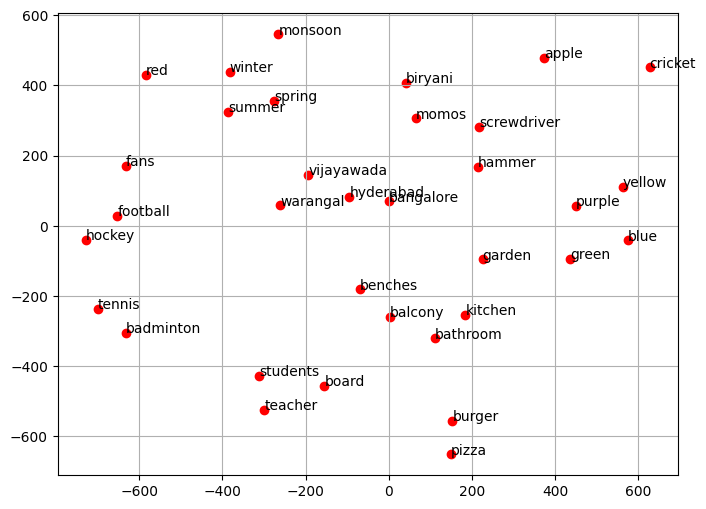

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(tsne_coordinates[:,0], tsne_coordinates[:,1], c='red')
plt.grid()
filtered_words_for_tsne = [word for word in words if word in glove_model]

for i, word in enumerate(filtered_words_for_tsne):
    plt.annotate(word, (tsne_coordinates[i,0], tsne_coordinates[i,1]))

plt.show()